# ЛР №6

Основные понятия ООП. Инкапсуляция. Классы. Декораторы.

## Основная задача "Эксперимент"

Нужно написать класс "Эксперимент", который производит работу с данными.

Вы получили данные в виде словаря. Словарь имеет следующую структуру {'date': '2023-01-05', 'signal': 'path_to_ecg_signal', 'parameters':{}}

**Интерфейс**

Нужно написать класс, где должны поддерживаться следующие методы:

* _конструктор_ — принимает словарь и создает соответствующие поля (self.date, self.path_signal, self.parameters)
* `get_datе()` — возвращает дату записи сигнала.
* `get_signal_length()` — возвращает длину сигнала.
* `plot_signal()` — выводит график сигнала.
* `_signal_filtration(signal, filtration_parameters)` — производит фильтрацию сигнала.
* `_signal_find_peaks(signal, find_peaks_parameters)` — находит точки максимума сигнала и возвращает их в виде списка.
* `_calculate_RR_intervals()` — производит расчет длительности RR интервалов и возвращает длины RR интервалов в виде списка.
В этом методе вызываются методы _signal_filtration и _signal_find_peak.
* `get_RR_statistics()` — возвращает статистические характеристики RR интервалов на записи ECG - среднее, std, min, max (в виде словаря).
В этом методе вызывается метод _calculate_RR_intervals.


*можно добавить свои методы






Файл с ЭКГ сигналом (ecg.csv)

https://drive.google.com/file/d/1bJ8hsAJCubPjPQj2CiyEliBBndfIqE6V/view?usp=drive_link

In [4]:
# модули, которые нам понадобятся
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
# import wfdb
import heartpy as hp
from scipy.signal import find_peaks

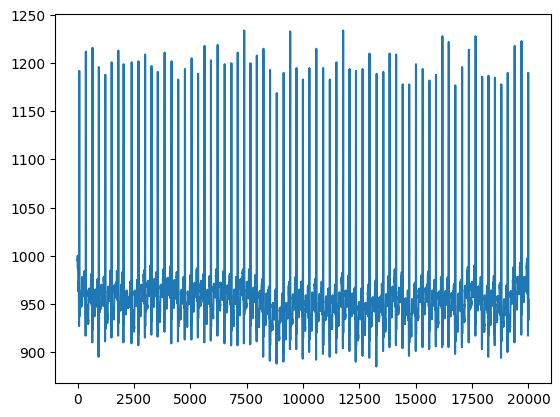

In [2]:
# загрузка сигнала из .csv файла с pandas
df = pd.read_csv('ecg.csv')
plt.plot(df['MLII'])
plt.show()

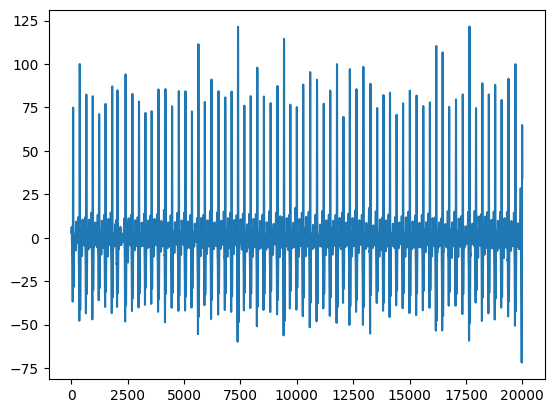

In [5]:
# фильтрация сигнала с библиотекой heartpy
filtered = hp.filter_signal(df['MLII'], cutoff=[0.75, 3.5], sample_rate=100, order=3, filtertype='bandpass')
plt.plot(filtered)
plt.show()

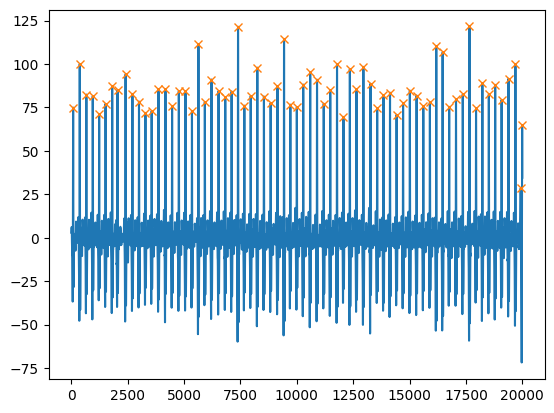

In [7]:
# поиск точек максимума с библиотекой scipy
peaks, _ = find_peaks(filtered, height=20)
plt.plot(filtered)
plt.plot(peaks, filtered[peaks], 'x')
plt.show()

In [8]:
{'date': '2023-01-05',
 'signal': 'path_to_ecg_signal',
 'parameters':{
     'filtration_parameters': {'cutoff': [0.75, 3.5], 'sample_rate': 100, 'order': 3, 'filtertype': 'bandpass'},
     'find_peaks_parameters': {'height': 20},
 }
 }

{'date': '2023-01-05',
 'signal': 'path_to_ecg_signal',
 'parameters': {'filtration_parameters': {'cutoff': [0.75, 3.5],
   'sample_rate': 100,
   'order': 3,
   'filtertype': 'bandpass'},
  'find_peaks_parameters': {'height': 20}}}

In [9]:
par = {'cutoff': [0.75, 3.5], 'sample_rate': 100, 'order': 3, 'filtertype': 'bandpass'}

In [10]:
hp.filter_signal(df['MLII'], **par)

array([ 2.93669972,  3.29570765,  3.67201131, ..., 46.85395203,
       40.8126148 , 34.54963788])

## Задача ** "Минигольф"

https://drive.google.com/drive/folders/1yT0TuqoQuLhPgGFZl-uUjVq8iKFAGGpX?usp=drive_link